In [ ]:
import numpy as np



In [ ]:
from math import prod


np.float64(1.1064738375689762)

In [ ]:
n = 1000
m = 1000
a = np.random.lognormal(size=(n, m))

res = prod(a) ** (1/n)

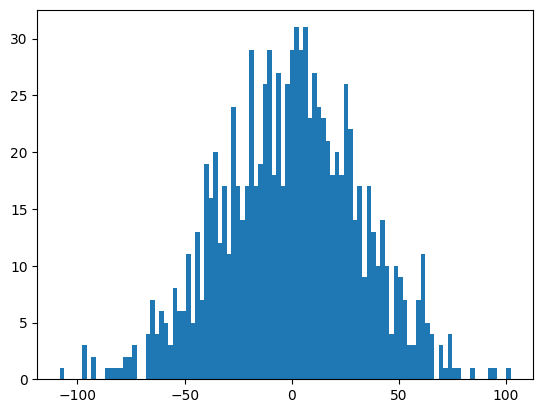

In [ ]:
plt.hist(np.log(a).sum(axis=0), bins=100)
plt.show()

In [ ]:
np.log(a).sum(axis=0).std()

np.float64(32.595009851530875)

In [ ]:
import matplotlib.pyplot as plt

(array([ 10.,  69., 137., 270., 234., 144.,  90.,  34.,   9.,   3.]),
 array([0.72450491, 0.79094678, 0.85738866, 0.92383054, 0.99027241,
        1.05671429, 1.12315616, 1.18959804, 1.25603992, 1.32248179,
        1.38892367]),
 <BarContainer object of 10 artists>)

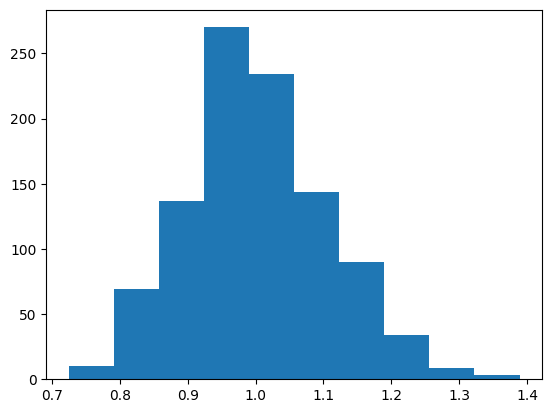

In [ ]:
plt.hist(res)

In [ ]:
1/(1000**(1/2))

0.03162277660168379

((array([  4.,  17.,  77., 161., 227., 236., 167.,  76.,  25.,  10.]),
  array([-0.09501174, -0.07604068, -0.05706961, -0.03809854, -0.01912747,
         -0.0001564 ,  0.01881467,  0.03778574,  0.05675681,  0.07572787,
          0.09469894]),
  <BarContainer object of 10 artists>),
 np.float64(0.9596421755275224))

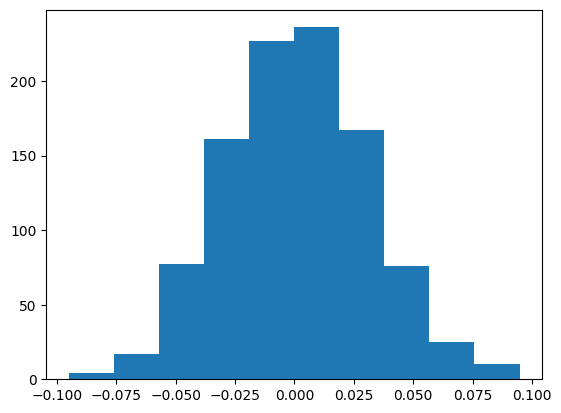

In [ ]:
plt.hist(np.log(res)), np.log(res).std() * np.sqrt(n)

In [ ]:
import yfinance as yf

In [ ]:
import yfinance as yf
import pandas as pd

vt = False

if vt:
    # 1. Set the ticker
    ticker = yf.Ticker("VT")

    # 2. Download full history (from inception)
    #    VT started trading on 2008-06-24 :contentReference[oaicite:0]{index=0}
    hist = ticker.history(start="2008-06-24", end="2027-01-01")
else:
    
    ticker = yf.Ticker("SPY")
    hist = ticker.history(start="1993-01-01")


# 3. Ensure the index is a DateTimeIndex
hist.index = pd.to_datetime(hist.index)

# 4. Group by year and extract the last available trading day's close price
yearly = hist["Close"].resample("YE").last()

# 5. Print the results
# print(yearly)

Date
1993-12-31 00:00:00-05:00     26.352627
1994-12-31 00:00:00-05:00     26.457333
1995-12-31 00:00:00-05:00     36.524075
1996-12-31 00:00:00-05:00     44.741047
1997-12-31 00:00:00-05:00     59.718185
1998-12-31 00:00:00-05:00     76.852814
1999-12-31 00:00:00-05:00     92.522560
2000-12-31 00:00:00-05:00     83.509476
2001-12-31 00:00:00-05:00     73.689995
2002-12-31 00:00:00-05:00     57.784294
2003-12-31 00:00:00-05:00     74.068810
2004-12-31 00:00:00-05:00     81.992645
2005-12-31 00:00:00-05:00     85.951492
2006-12-31 00:00:00-05:00     99.570740
2007-12-31 00:00:00-05:00    104.694794
2008-12-31 00:00:00-05:00     66.172356
2009-12-31 00:00:00-05:00     83.609940
2010-12-31 00:00:00-05:00     96.198387
2011-12-31 00:00:00-05:00     98.021339
2012-12-31 00:00:00-05:00    113.695259
2013-12-31 00:00:00-05:00    150.427597
2014-12-31 00:00:00-05:00    170.680954
2015-12-31 00:00:00-05:00    172.787659
2016-12-31 00:00:00-05:00    193.518539
2017-12-31 00:00:00-05:00    235.52

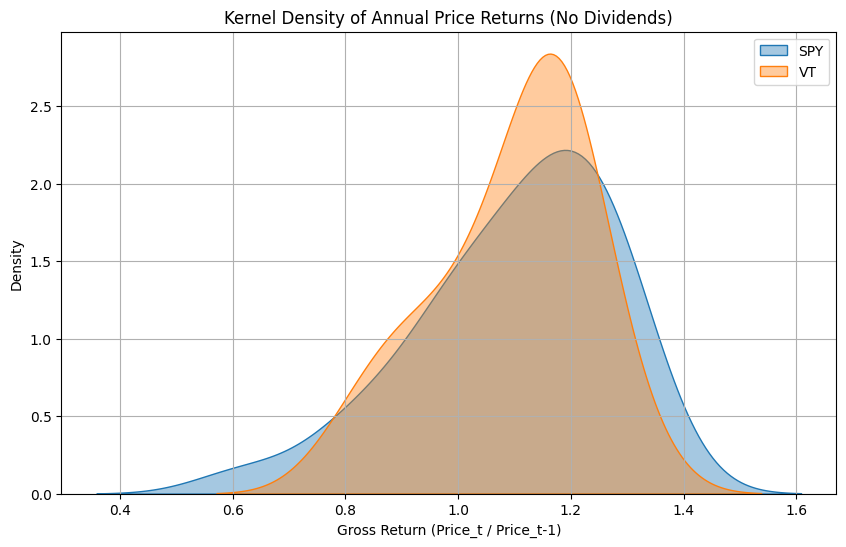

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. Download data (NO auto adjust)
# -------------------------
tickers = ["SPY", "VT"]

data = yf.download(
    tickers,
    start="1993-01-01",
    auto_adjust=False,
    progress=False
)

prices = data["Close"]

# -------------------------
# 2. End-of-year prices
# -------------------------
yearly = prices.resample("YE").last()

# Align series (VT starts later)
# yearly = yearly.dropna()

# -------------------------
# 3. Returns
# -------------------------
returns = yearly / yearly.shift(1)
# returns = returns.dropna()

# -------------------------
# 4. KDE Plot
# -------------------------
plt.figure(figsize=(10,6))

sns.kdeplot(returns["SPY"], label="SPY", fill=True, alpha=0.4)
sns.kdeplot(returns["VT"], label="VT", fill=True, alpha=0.4)

plt.title("Kernel Density of Annual Price Returns (No Dividends)")
plt.xlabel("Gross Return (Price_t / Price_t-1)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

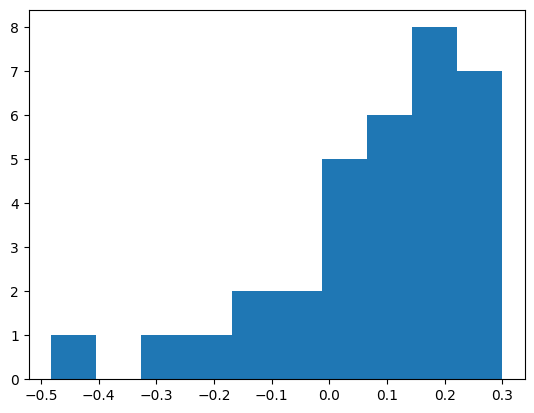

In [ ]:
plt.hist(np.log(returns["SPY"]))
plt.show()

In [ ]:
log_returns = np.log(returns)

In [ ]:
log_returns["SPY"]

Date
1993-12-31         NaN
1994-12-31   -0.022381
1995-12-31    0.299698
1996-12-31    0.183168
1997-12-31    0.273404
1998-12-31    0.239367
1999-12-31    0.174860
2000-12-31   -0.112954
2001-12-31   -0.137801
2002-12-31   -0.258880
2003-12-31    0.232102
2004-12-31    0.082666
2005-12-31    0.029670
2006-12-31    0.128761
2007-12-31    0.031897
2008-12-31   -0.482571
2009-12-31    0.211014
2010-12-31    0.120809
2011-12-31   -0.001990
2012-12-31    0.126404
2013-12-31    0.259969
2014-12-31    0.106962
2015-12-31   -0.008158
2016-12-31    0.092063
2017-12-31    0.177178
2018-12-31   -0.065583
2019-12-31    0.252976
2020-12-31    0.149818
2021-12-31    0.239296
2022-12-31   -0.216685
2023-12-31    0.217422
2024-12-31    0.209489
2025-12-31    0.151456
2026-12-31    0.005951
Freq: YE-DEC, Name: SPY, dtype: float64

In [ ]:
from scipy.stats import t

params = t.fit(log_returns["SPY"].dropna())
df, loc, scale = params
df, loc, scale

(np.float64(4.413454552834478),
 np.float64(0.11116138062917191),
 np.float64(0.13102284620048255))

In [ ]:
from scipy.stats import skew, kurtosis

print("Skew:", skew(log_returns["SPY"].dropna()))
print("Kurtosis:", kurtosis(log_returns["SPY"].dropna(), fisher=False))

Skew: -1.298305338967481
Kurtosis: 4.644353177084459


In [ ]:
log_returns = np.log(returns["SPY"]).dropna().values

In [ ]:
import numpy as np
from scipy.stats import t
from scipy.optimize import minimize

# Skew-t log likelihood
def skewt_loglik(params, data):
    mu, sigma, nu, alpha = params
    
    # Parameter constraints
    if sigma <= 0 or nu <= 2:
        return np.inf
    
    z = (data - mu) / sigma
    
    # Student-t pdf
    pdf = t.pdf(z, df=nu)
    
    # Student-t cdf
    cdf = t.cdf(
        alpha * z * np.sqrt((nu + 1) / (nu + z**2)),
        df=nu + 1
    )
    
    likelihood = 2 / sigma * pdf * cdf
    
    # Avoid log(0)
    if np.any(likelihood <= 0):
        return np.inf
    
    return -np.sum(np.log(likelihood))


# Initial guesses
mu_init = np.mean(log_returns)
sigma_init = np.std(log_returns)
nu_init = 8
alpha_init = -2  # negative skew guess

initial_params = [mu_init, sigma_init, nu_init, alpha_init]

# Optimize
result = minimize(
    skewt_loglik,
    initial_params,
    args=(log_returns,),
    method="L-BFGS-B",
    bounds=[
        (None, None),      # mu
        (1e-6, None),      # sigma
        (2.01, 100),       # nu
        (None, None)       # alpha
    ]
)

mu_hat, sigma_hat, nu_hat, alpha_hat = result.x

print("Skew-t MLE estimates:")
print("mu    =", mu_hat)
print("sigma =", sigma_hat)
print("nu    =", nu_hat)
print("alpha =", alpha_hat)

Skew-t MLE estimates:
mu    = 0.2851069139746102
sigma = 0.23562459923935336
nu    = 9.022337593435708
alpha = -11.650977992333603


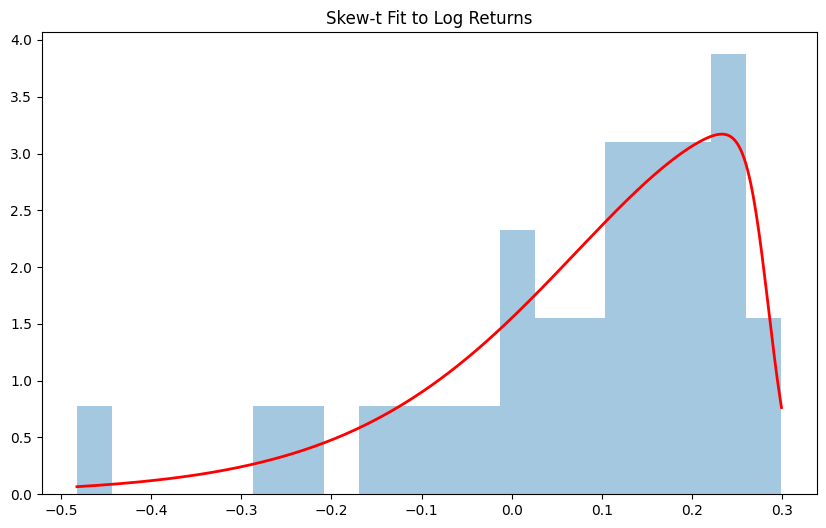

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import t

def skewt_pdf(x, mu, sigma, nu, alpha):
    z = (x - mu) / sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(
        alpha * z * np.sqrt((nu + 1) / (nu + z**2)),
        df=nu + 1
    )
    return 2 / sigma * pdf * cdf


x = np.linspace(log_returns.min(), log_returns.max(), 500)
pdf_vals = skewt_pdf(x, mu_hat, sigma_hat, nu_hat, alpha_hat)

plt.figure(figsize=(10,6))
plt.hist(log_returns, bins=20, density=True, alpha=0.4)
plt.plot(x, pdf_vals, 'r', lw=2)
plt.title("Skew-t Fit to Log Returns")
plt.show()

In [ ]:
print("Converged:", result.success)
print("Log-likelihood:", -result.fun)

Converged: True
Log-likelihood: 17.929377216711753


=== SPY ===
Lognormal AIC=-12.98, BIC=-9.93
Skew-t    AIC=-27.86, BIC=-21.75

=== VT ===
Lognormal AIC=-15.74, BIC=-12.69
Skew-t    AIC=-19.23, BIC=-13.13


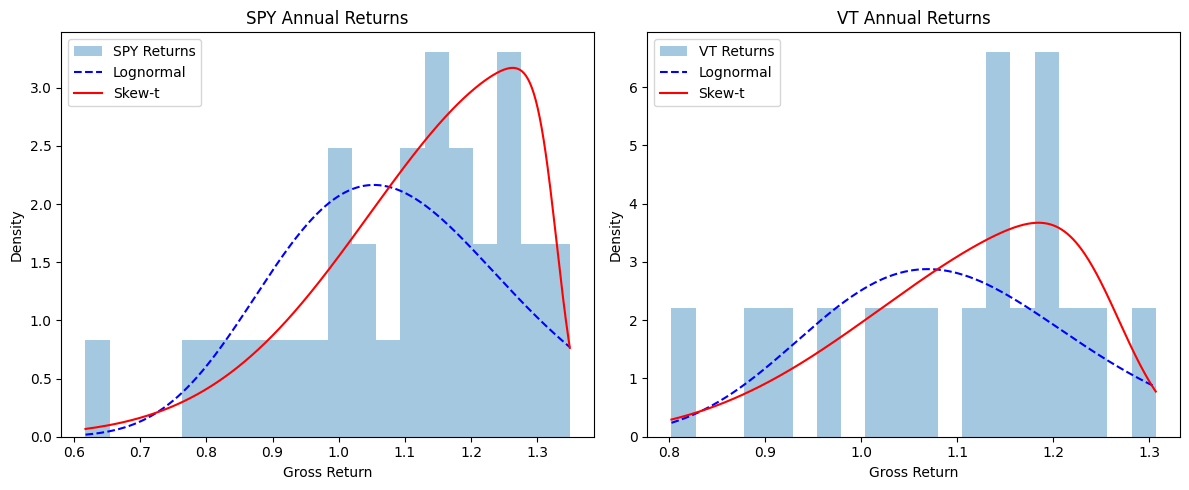

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, t
from scipy.optimize import minimize

# -------------------------
# 1. Download gross prices
# -------------------------
tickers = ["SPY", "VT"]
data = yf.download(tickers, start="1993-01-01", auto_adjust=False, progress=False)
prices = data["Close"]

# End-of-year prices
yearly = prices.resample("YE").last()
returns = yearly / yearly.shift(1)
# returns = returns.dropna()

# -------------------------
# 2. Fit lognormal
# -------------------------
def fit_lognormal(data):
    shape, loc, scale = lognorm.fit(data, floc=0)  # force loc=0
    mu = np.log(scale)
    sigma = shape
    ll = np.sum(lognorm.logpdf(data, s=shape, loc=0, scale=scale))
    return mu, sigma, ll, shape, scale

mu_ln_spy, sigma_ln_spy, ll_ln_spy, shape_spy, scale_spy = fit_lognormal(returns["SPY"].dropna())
mu_ln_vt, sigma_ln_vt, ll_ln_vt, shape_vt, scale_vt = fit_lognormal(returns["VT"].dropna())

# -------------------------
# 3. Fit skew-t
# -------------------------
log_returns_spy = np.log(returns["SPY"].dropna().values)
log_returns_vt  = np.log(returns["VT"].dropna().values)

def skewt_loglik(params, data):
    mu, sigma, nu, alpha = params
    if sigma <= 0 or nu <= 2:
        return np.inf
    z = (data - mu) / sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(alpha * z * np.sqrt((nu+1)/(nu+z**2)), df=nu+1)
    likelihood = 2 / sigma * pdf * cdf
    if np.any(likelihood <= 0):
        return np.inf
    return -np.sum(np.log(likelihood))

def fit_skewt(data):
    mu_init = np.mean(data)
    sigma_init = np.std(data)
    nu_init = 8
    alpha_init = -2
    initial_params = [mu_init, sigma_init, nu_init, alpha_init]
    result = minimize(skewt_loglik, initial_params, args=(data,), method="L-BFGS-B",
                      bounds=[(None,None),(1e-6,None),(2.01,100),(None,None)])
    return result

result_spy = fit_skewt(log_returns_spy)
result_vt  = fit_skewt(log_returns_vt)

mu_st_spy, sigma_st_spy, nu_st_spy, alpha_st_spy = result_spy.x
mu_st_vt, sigma_st_vt, nu_st_vt, alpha_st_vt = result_vt.x
ll_st_spy = -result_spy.fun
ll_st_vt  = -result_vt.fun

# -------------------------
# 4. Compute AIC/BIC
# -------------------------
n_spy = len(returns["SPY"])
n_vt  = len(returns["VT"])

def aic_bic(ll, k, n):
    aic = 2*k - 2*ll
    bic = k*np.log(n) - 2*ll
    return aic, bic

aic_ln_spy, bic_ln_spy = aic_bic(ll_ln_spy, 2, n_spy)
aic_ln_vt, bic_ln_vt   = aic_bic(ll_ln_vt, 2, n_vt)
aic_st_spy, bic_st_spy = aic_bic(ll_st_spy, 4, n_spy)
aic_st_vt, bic_st_vt   = aic_bic(ll_st_vt, 4, n_vt)

print("=== SPY ===")
print(f"Lognormal AIC={aic_ln_spy:.2f}, BIC={bic_ln_spy:.2f}")
print(f"Skew-t    AIC={aic_st_spy:.2f}, BIC={bic_st_spy:.2f}\n")

print("=== VT ===")
print(f"Lognormal AIC={aic_ln_vt:.2f}, BIC={bic_ln_vt:.2f}")
print(f"Skew-t    AIC={aic_st_vt:.2f}, BIC={bic_st_vt:.2f}")

# -------------------------
# 5. Plot histogram + PDFs
# -------------------------
def skewt_pdf(x, mu, sigma, nu, alpha):
    z = (x - mu)/sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(alpha * z * np.sqrt((nu+1)/(nu+z**2)), df=nu+1)
    return 2 / sigma * pdf * cdf

x_spy = np.linspace(returns["SPY"].min(), returns["SPY"].max(), 500)
x_vt  = np.linspace(returns["VT"].min(), returns["VT"].max(), 500)

plt.figure(figsize=(12,5))

# SPY
plt.subplot(1,2,1)
plt.hist(returns["SPY"], bins=20, density=True, alpha=0.4, label="SPY Returns")
plt.plot(x_spy, lognorm.pdf(x_spy, s=shape_spy, loc=0, scale=scale_spy), 'b--', label="Lognormal")
plt.plot(x_spy, skewt_pdf(np.log(x_spy), mu_st_spy, sigma_st_spy, nu_st_spy, alpha_st_spy), 'r-', label="Skew-t")
plt.title("SPY Annual Returns")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()

# VT
plt.subplot(1,2,2)
plt.hist(returns["VT"], bins=20, density=True, alpha=0.4, label="VT Returns")
plt.plot(x_vt, lognorm.pdf(x_vt, s=shape_vt, loc=0, scale=scale_vt), 'b--', label="Lognormal")
plt.plot(x_vt, skewt_pdf(np.log(x_vt), mu_st_vt, sigma_st_vt, nu_st_vt, alpha_st_vt), 'r-', label="Skew-t")
plt.title("VT Annual Returns")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

Lognormal: AIC=-12.98, BIC=-9.99
Skew-t:    AIC=-27.86, BIC=-21.87


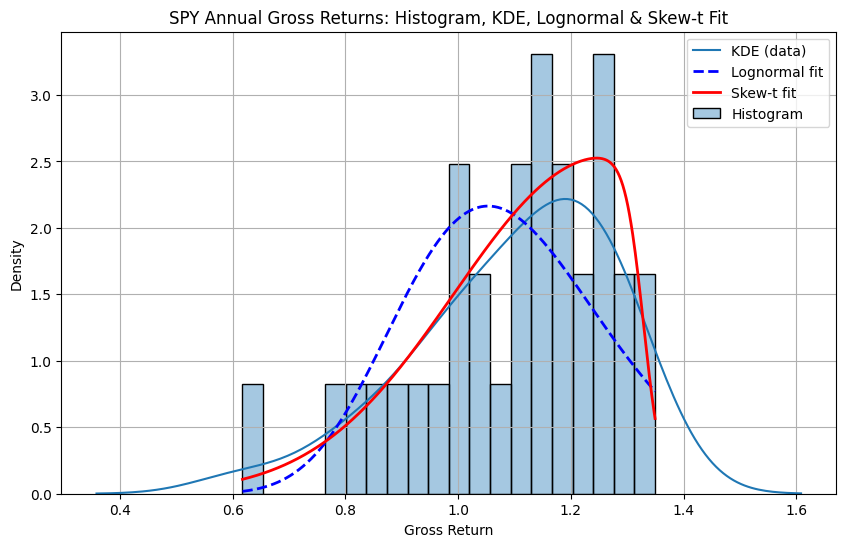

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, t
from scipy.optimize import minimize
import seaborn as sns

# -------------------------
# 1. Download SPY prices
# -------------------------
data = yf.download("SPY", start="1993-01-01", auto_adjust=False, progress=False)
prices = data["Close"]

# End-of-year prices
yearly = prices.resample("YE").last()
returns = yearly / yearly.shift(1)
returns = returns.dropna()
data_spy = returns.values

# -------------------------
# 2. Fit lognormal
# -------------------------
shape_ln, loc_ln, scale_ln = lognorm.fit(data_spy, floc=0)
mu_ln = np.log(scale_ln)
sigma_ln = shape_ln
ll_ln = np.sum(lognorm.logpdf(data_spy, s=shape_ln, loc=0, scale=scale_ln))
aic_ln = 2*2 - 2*ll_ln
bic_ln = 2*np.log(len(data_spy)) - 2*ll_ln

# -------------------------
# 3. Fit skew-t
# -------------------------
log_returns = np.log(data_spy)

def skewt_loglik(params, data):
    mu, sigma, nu, alpha = params
    if sigma <= 0 or nu <= 2:
        return np.inf
    z = (data - mu)/sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(alpha * z * np.sqrt((nu+1)/(nu+z**2)), df=nu+1)
    likelihood = 2 / sigma * pdf * cdf
    if np.any(likelihood <= 0):
        return np.inf
    return -np.sum(np.log(likelihood))

mu_init = np.mean(log_returns)
sigma_init = np.std(log_returns)
nu_init = 8
alpha_init = -2
result = minimize(skewt_loglik, [mu_init, sigma_init, nu_init, alpha_init], 
                  args=(log_returns,), method="L-BFGS-B",
                  bounds=[(None,None),(1e-6,None),(2.01,100),(None,None)])
mu_st, sigma_st, nu_st, alpha_st = result.x
ll_st = -result.fun
aic_st, bic_st = 2*4 - 2*ll_st, 4*np.log(len(data_spy)) - 2*ll_st

print(f"Lognormal: AIC={aic_ln:.2f}, BIC={bic_ln:.2f}")
print(f"Skew-t:    AIC={aic_st:.2f}, BIC={bic_st:.2f}")

# -------------------------
# 4. Plot histogram + KDE + fitted PDFs
# -------------------------
x = np.linspace(data_spy.min(), data_spy.max(), 500)

def skewt_pdf(x, mu, sigma, nu, alpha):
    z = (np.log(x) - mu)/sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(alpha * z * np.sqrt((nu+1)/(nu+z**2)), df=nu+1)
    return 2 / (sigma*x) * pdf * cdf  # note 1/x for change of variable

plt.figure(figsize=(10,6))
sns.histplot(data_spy, bins=20, stat="density", alpha=0.4, color="gray", label="Histogram")
sns.kdeplot(data_spy, fill=False, color="black", label="KDE (data)")

plt.plot(x, lognorm.pdf(x, s=shape_ln, loc=0, scale=scale_ln), 'b--', lw=2, label="Lognormal fit")
plt.plot(x, skewt_pdf(x, mu_st, sigma_st, nu_st, alpha_st), 'r-', lw=2, label="Skew-t fit")

plt.title("SPY Annual Gross Returns: Histogram, KDE, Lognormal & Skew-t Fit")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from scipy.stats import lognorm

# Number of simulated years
n_sim = 10000

# Draw from fitted lognormal
sim_lognormal = lognorm.rvs(s=shape_ln, scale=scale_ln, size=n_sim, random_state=42)

# Quick check
print("Lognormal simulated mean:", np.mean(sim_lognormal))
print("Lognormal simulated min/max:", sim_lognormal.min(), sim_lognormal.max())

Lognormal simulated mean: 1.1008701304474398
Lognormal simulated min/max: 0.551624201367586 2.135164581299454


In [ ]:
from scipy.stats import t

def skewt_rvs(mu, sigma, nu, alpha, size=1, random_state=None):
    rng = np.random.default_rng(random_state)
    
    # Step 1: standard t random variable
    y = t.rvs(df=nu, size=size, random_state=rng)
    
    # Step 2: skew transform
    delta = alpha / np.sqrt(1 + alpha**2)
    u = rng.uniform(size=size)
    sign = np.sign(u - t.cdf(0, df=nu))
    z = y * sign  # reflect based on uniform
    x = mu + sigma * z
    return np.exp(x)  # back-transform from log returns to gross returns

# Simulate
sim_skewt = skewt_rvs(mu_st, sigma_st, nu_st, alpha_st, size=n_sim, random_state=42)

print("Skew-t simulated mean:", np.mean(sim_skewt))
print("Skew-t simulated min/max:", sim_skewt.min(), sim_skewt.max())

Skew-t simulated mean: 1.3748779266677766
Skew-t simulated min/max: 0.3754729843299667 5.5749762106532685


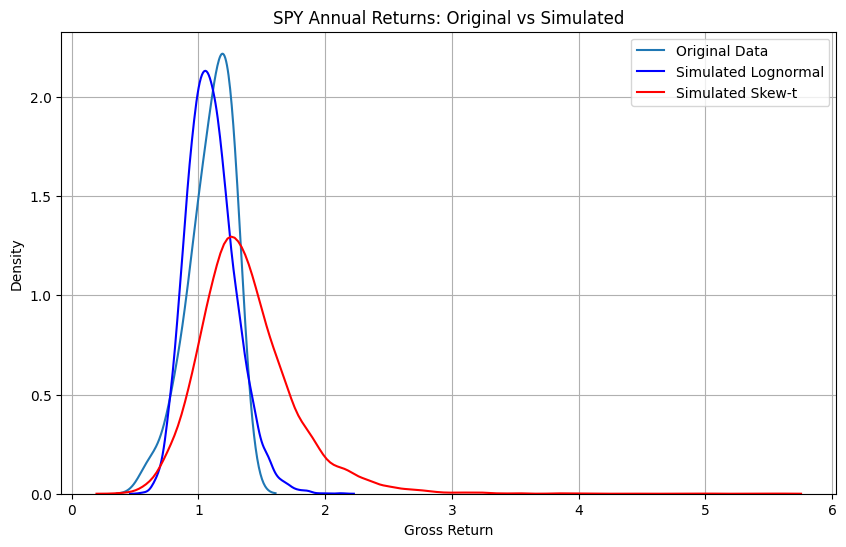

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(data_spy, label="Original Data", color="black")
sns.kdeplot(sim_lognormal, label="Simulated Lognormal", color="blue")
sns.kdeplot(sim_skewt, label="Simulated Skew-t", color="red")
plt.title("SPY Annual Returns: Original vs Simulated")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

def skewt_rvs_correct(mu, sigma, nu, alpha, size=1, random_state=None):
    rng = np.random.default_rng(random_state)
    delta = alpha / np.sqrt(1 + alpha**2)
    
    # Standard normal independent variables
    u0 = rng.normal(size=size)
    u1 = rng.normal(size=size)
    
    # Chi-squared for Student-t
    v = rng.chisquare(df=nu, size=size)
    
    # Skew-t random variable (log return)
    x = mu + sigma * (delta * np.abs(u0) + np.sqrt(1 - delta**2) * u1) / np.sqrt(v / nu)
    
    # Transform to gross returns
    R = np.exp(x)
    return R

# Simulate
n_sim = 10000
sim_skewt_correct = skewt_rvs_correct(mu_st, sigma_st, nu_st, alpha_st, size=n_sim, random_state=42)

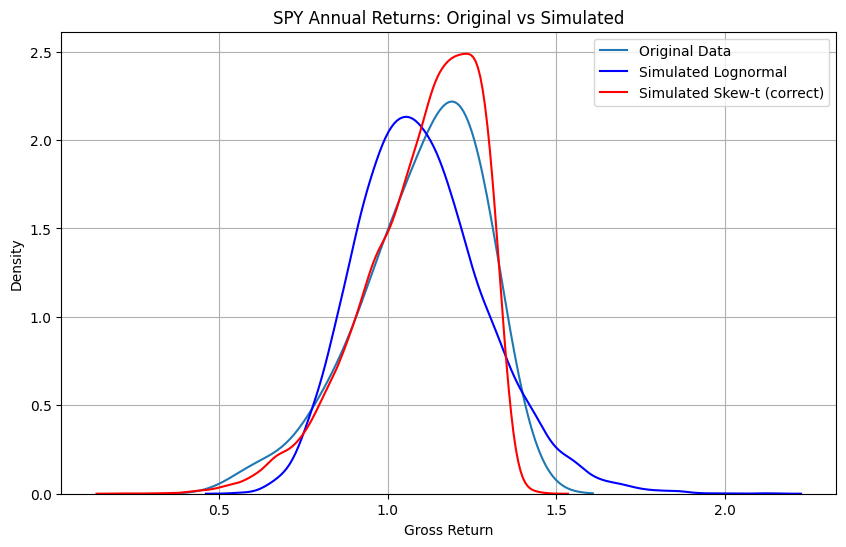

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm

# Lognormal simulation
sim_lognormal = lognorm.rvs(s=shape_ln, scale=scale_ln, size=n_sim, random_state=42)

plt.figure(figsize=(10,6))
sns.kdeplot(data_spy, label="Original Data", color="black")
sns.kdeplot(sim_lognormal, label="Simulated Lognormal", color="blue")
sns.kdeplot(sim_skewt_correct, label="Simulated Skew-t (correct)", color="red")
plt.title("SPY Annual Returns: Original vs Simulated")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# assume `returns` already exists from earlier code
# and contains gross returns

def fit_lognormal(series):
    log_returns = np.log(series)
    mu = log_returns.mean()
    sigma = log_returns.std(ddof=0)  # MLE uses population std (ddof=0)
    return mu, sigma

# Fit both
mu_spy, sigma_spy = fit_lognormal(returns["SPY"])
mu_vt, sigma_vt = fit_lognormal(returns["VT"])

print("SPY lognormal MLE:")
print("mu =", mu_spy)
print("sigma =", sigma_spy)

print("\nVT lognormal MLE:")
print("mu =", mu_vt)
print("sigma =", sigma_vt)

SPY lognormal MLE:
mu = 0.11268834844707591
sigma = 0.12350821012909693

VT lognormal MLE:
mu = 0.08334607110395542
sigma = 0.12864134421358117


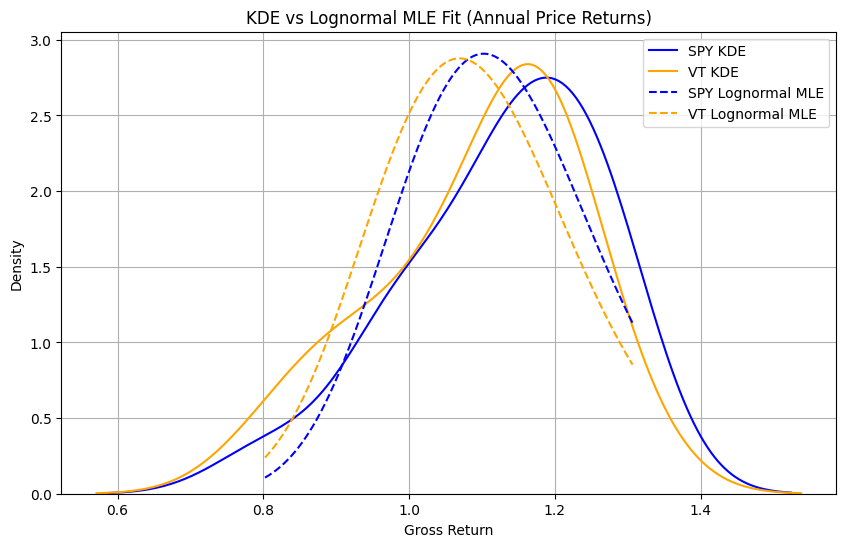

In [ ]:
x = np.linspace(returns.min().min(), returns.max().max(), 500)

plt.figure(figsize=(10,6))

# KDE
sns.kdeplot(returns["SPY"], label="SPY KDE", color="blue")
sns.kdeplot(returns["VT"], label="VT KDE", color="orange")

# Lognormal PDFs
pdf_spy = stats.lognorm.pdf(x, s=sigma_spy, scale=np.exp(mu_spy))
pdf_vt = stats.lognorm.pdf(x, s=sigma_vt, scale=np.exp(mu_vt))

plt.plot(x, pdf_spy, linestyle="--", color="blue", label="SPY Lognormal MLE")
plt.plot(x, pdf_vt, linestyle="--", color="orange", label="VT Lognormal MLE")

plt.title("KDE vs Lognormal MLE Fit (Annual Price Returns)")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

Lognormal: AIC=-12.98, BIC=-9.99
Skew-t:    AIC=-27.86, BIC=-21.87


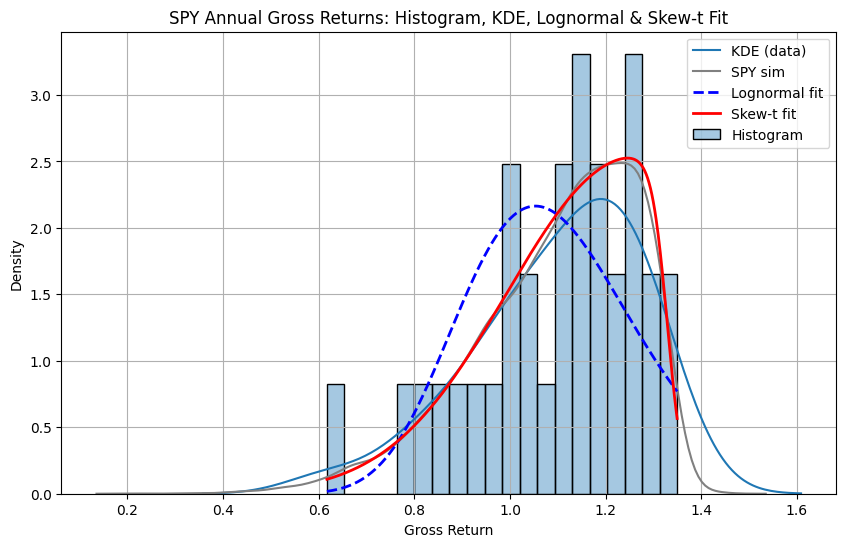

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm, t
from scipy.optimize import minimize

# -------------------------
# 1. Download SPY end-of-year prices
# -------------------------
data = yf.download("SPY", start="1993-01-01", auto_adjust=False, progress=False)
prices = data["Close"]

yearly = prices.resample("YE").last()
returns = yearly / yearly.shift(1)
returns = returns.dropna()
data_spy = returns.values

# -------------------------
# 2. Fit lognormal
# -------------------------
shape_ln, loc_ln, scale_ln = lognorm.fit(data_spy, floc=0)
mu_ln = np.log(scale_ln)
sigma_ln = shape_ln
ll_ln = np.sum(lognorm.logpdf(data_spy, s=shape_ln, loc=0, scale=scale_ln))
aic_ln = 2*2 - 2*ll_ln
bic_ln = 2*np.log(len(data_spy)) - 2*ll_ln

# -------------------------
# 3. Fit skew-t on log returns
# -------------------------
log_returns = np.log(data_spy)

def skewt_loglik(params, data):
    mu, sigma, nu, alpha = params
    if sigma <= 0 or nu <= 2:
        return np.inf
    z = (data - mu)/sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(alpha * z * np.sqrt((nu+1)/(nu+z**2)), df=nu+1)
    likelihood = 2 / sigma * pdf * cdf
    if np.any(likelihood <= 0):
        return np.inf
    return -np.sum(np.log(likelihood))

# Initial guesses
mu_init = np.mean(log_returns)
sigma_init = np.std(log_returns)
nu_init = 8
alpha_init = -2
result = minimize(skewt_loglik, [mu_init, sigma_init, nu_init, alpha_init], 
                  args=(log_returns,), method="L-BFGS-B",
                  bounds=[(None,None),(1e-6,None),(2.01,100),(None,None)])
mu_st, sigma_st, nu_st, alpha_st = result.x
ll_st = -result.fun
aic_st, bic_st = 2*4 - 2*ll_st, 4*np.log(len(data_spy)) - 2*ll_st

print(f"Lognormal: AIC={aic_ln:.2f}, BIC={bic_ln:.2f}")
print(f"Skew-t:    AIC={aic_st:.2f}, BIC={bic_st:.2f}")

# -------------------------
# 4. Generate simulated returns
# -------------------------
n_sim = 10000

# Lognormal simulation
sim_lognormal = lognorm.rvs(s=shape_ln, scale=scale_ln, size=n_sim, random_state=42)

# Correct skew-t generator (Azzalini stochastic representation)
def skewt_rvs_correct(mu, sigma, nu, alpha, size=1, random_state=None):
    rng = np.random.default_rng(random_state)
    delta = alpha / np.sqrt(1 + alpha**2)
    
    u0 = rng.normal(size=size)
    u1 = rng.normal(size=size)
    v = rng.chisquare(df=nu, size=size)
    
    x = mu + sigma * (delta * np.abs(u0) + np.sqrt(1 - delta**2) * u1) / np.sqrt(v / nu)
    R = np.exp(x)  # back-transform to gross returns
    return R

sim_skewt = skewt_rvs_correct(mu_st, sigma_st, nu_st, alpha_st, size=n_sim, random_state=42)

# -------------------------
# 5. Plot histogram + KDE + fitted distributions
# -------------------------
x = np.linspace(data_spy.min(), data_spy.max(), 500)

def skewt_pdf(x, mu, sigma, nu, alpha):
    z = (np.log(x) - mu)/sigma
    pdf = t.pdf(z, df=nu)
    cdf = t.cdf(alpha * z * np.sqrt((nu+1)/(nu+z**2)), df=nu+1)
    return 2 / (sigma*x) * pdf * cdf  # change-of-variable

plt.figure(figsize=(10,6))
sns.histplot(data_spy, bins=20, stat="density", alpha=0.4, color="gray", label="Histogram")
sns.kdeplot(data_spy, fill=False, color="black", label="KDE (data)")
sns.kdeplot(sim_skewt, fill=False, color="gray", label="SPY sim")
# sns.histplot(sim_skewt, bins=20, stat="density", alpha=0.4, color="gray", label="SPY sim")

plt.plot(x, lognorm.pdf(x, s=shape_ln, loc=0, scale=scale_ln), 'b--', lw=2, label="Lognormal fit")
plt.plot(x, skewt_pdf(x, mu_st, sigma_st, nu_st, alpha_st), 'r-', lw=2, label="Skew-t fit")
plt.title("SPY Annual Gross Returns: Histogram, KDE, Lognormal & Skew-t Fit")
plt.xlabel("Gross Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sim_skewt

array([1.18737521, 1.04797257, 1.05906026, ..., 1.31968987, 0.93199308,
       1.28625572], shape=(10000,))